<a href="https://colab.research.google.com/github/SejalB15/DL-Practicals/blob/main/DL2A_Multiclass_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment No: 2A
## Multiclass Classification using Deep Neural Network
**Aim:** Multiclass classification using Deep Neural Networks.

**Dataset:** OCR Letter Recognition Dataset (UCI ML Repository)

**Task:** Classify 16 numeric features into one of 26 English letters (A–Z)

---

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print('TensorFlow:', tf.__version__)
print('All libraries imported!')

TensorFlow: 2.20.0
All libraries imported!


## Step 2: Load the Dataset

### 📥 Dataset Info:
The dataset is from UCI ML Repository. We load it directly using `fetch_openml` — **no manual download needed!**
- 20,000 samples, 16 features
- 26 classes (A to Z)

In [2]:
# Load OCR Letter Recognition dataset directly from OpenML
from sklearn.datasets import fetch_openml

print('Downloading dataset... (may take a moment)')
letter = fetch_openml(name='letter', version=1, as_frame=True)

X = letter.data.astype(float)
y = letter.target  # Labels: A-Z

print(f'Dataset shape   : {X.shape}')
print(f'Feature names   : {list(X.columns)}')
print(f'Classes         : {sorted(y.unique())}')
print(f'\nClass distribution:')
print(y.value_counts().sort_index())

Dataset shape   : (20000, 16)
Feature names   : ['x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar', 'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']
Classes         : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Class distribution:
class
A    789
B    766
C    736
D    805
E    768
F    775
G    773
H    734
I    755
J    747
K    739
L    761
M    792
N    783
O    753
P    803
Q    783
R    758
S    748
T    796
U    813
V    764
W    752
X    787
Y    786
Z    734
Name: count, dtype: int64


## Step 3: Exploratory Data Analysis

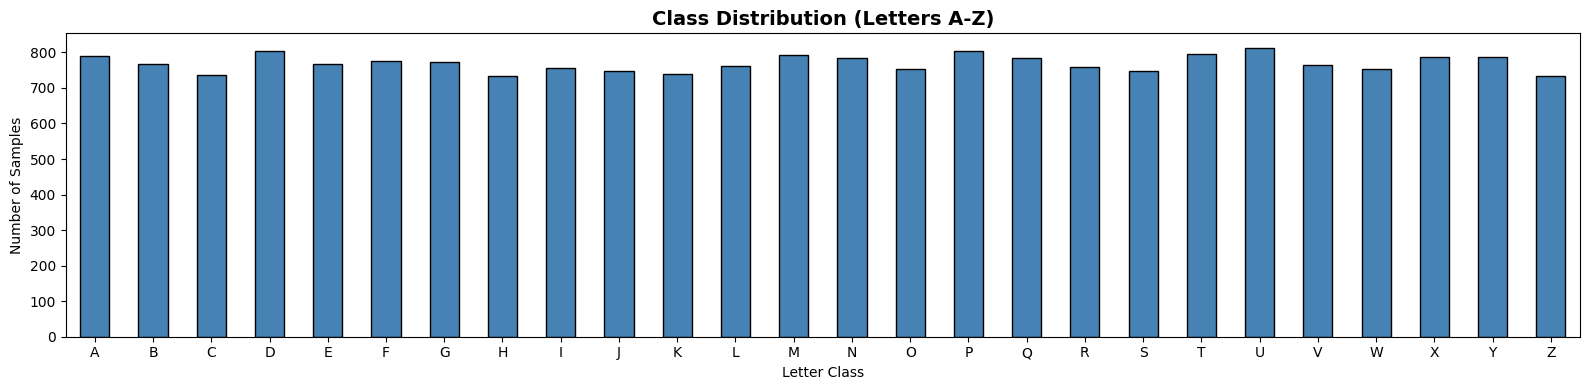


Dataset Statistics:


,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,4.023550,7.035500,5.121850,5.37245,3.505850,6.897600,7.500450,4.628600,5.178650,8.282050,6.45400,7.929000,3.046100,8.338850,3.691750,7.80120
std,1.913212,3.304555,2.014573,2.26139,2.190458,2.026035,2.325354,2.699968,2.380823,2.488475,2.63107,2.080619,2.332541,1.546722,2.567073,1.61747
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.000000,5.000000,4.000000,4.00000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,5.00000,7.000000,1.000000,8.000000,2.000000,7.00000
50%,4.000000,7.000000,5.000000,6.00000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,6.00000,8.000000,3.000000,8.000000,3.000000,8.00000
75%,5.000000,9.000000,6.000000,7.00000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,8.00000,9.000000,4.000000,9.000000,5.000000,9.00000
max,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.00000


In [3]:
# Class distribution bar chart
plt.figure(figsize=(16, 4))
y.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution (Letters A-Z)', fontsize=14, fontweight='bold')
plt.xlabel('Letter Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nDataset Statistics:')
X.describe()

## Step 4: Data Preprocessing

In [4]:
# Encode labels A-Z to 0-25
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print(f'Number of classes: {num_classes}')
print(f'Label mapping sample: A={le.transform(["A"])[0]}, Z={le.transform(["Z"])[0]}')

# One-hot encode labels for DNN
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Train-Test split (80-20)
X_train, X_test, y_train, y_test, y_enc_train, y_enc_test = train_test_split(
    X, y_categorical, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

# Standardize features
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print('Preprocessing complete!')

Number of classes: 26
Label mapping sample: A=0, Z=25

Training samples : 16000
Testing samples  : 4000
Preprocessing complete!


## Step 5: Build the Deep Neural Network

In [5]:
model = Sequential([
    # Input + Hidden Layer 1
    Dense(256, activation='relu', input_dim=16),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output Layer: 26 classes with softmax
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # For multiclass classification
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,730 (190.35 KB)

 Trainable params: 47,962 (187.35 KB)

 Non-trainable params: 768 (3.00 KB)

## Step 6: Train the Model

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

history = model.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\nTraining complete!')

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4803 - loss: 1.7958 - val_accuracy: 0.7244 - val_loss: 1.2726 - learning_rate: 0.0010
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6970 - loss: 1.0009 - val_accuracy: 0.8044 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7500 - loss: 0.8030 - val_accuracy: 0.8475 - val_loss: 0.5278 - learning_rate: 0.0010
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7811 - loss: 0.7064 - val_accuracy: 0.8619 - val_loss: 0.4498 - learning_rate: 0.0010
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7961 - loss: 0.6383 - val_accuracy: 0.8844 - val_loss: 0.3979 - learning_rate: 0.0010
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8113 - loss: 0.5898 - val_accuracy: 0.8956 - val_loss: 0.3550 - learning_rate: 0.0010
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8259 - loss: 0.

## Step 7: Plot Training Results

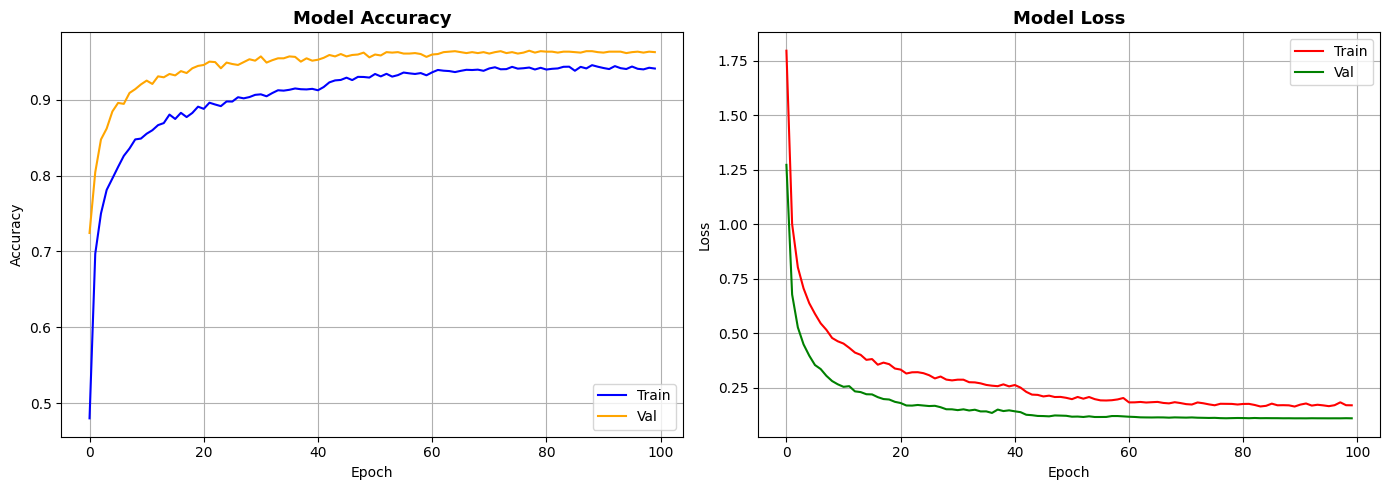

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train', color='red')
axes[1].plot(history.history['val_loss'], label='Val',   color='green')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('dl2a_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Evaluate the Model

In [8]:
test_loss, test_acc = model.evaluate(X_test_sc, y_test, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

# Detailed classification report
y_pred = np.argmax(model.predict(X_test_sc), axis=1)
print('\nClassification Report:')
print(classification_report(y_enc_test, y_pred, target_names=le.classes_))

Test Accuracy : 96.95%
Test Loss     : 0.0888
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.98      0.99       158
           B       0.93      0.95      0.94       153
           C       0.99      0.95      0.97       147
           D       0.95      0.99      0.97       161
           E       0.93      0.99      0.96       154
           F       0.97      0.95      0.96       155
           G       0.98      0.94      0.96       155
           H       0.94      0.93      0.93       147
           I       0.98      0.93      0.96       151
           J       0.94      0.97      0.96       149
           K       0.96      0.92      0.94       148
           L       1.00      0.98      0.99       152
           M       0.99      0.99      0.99       158
           N       0.97      0.98      0.98       157
           O       0.97      1.00      0.98       150
           P       0.9

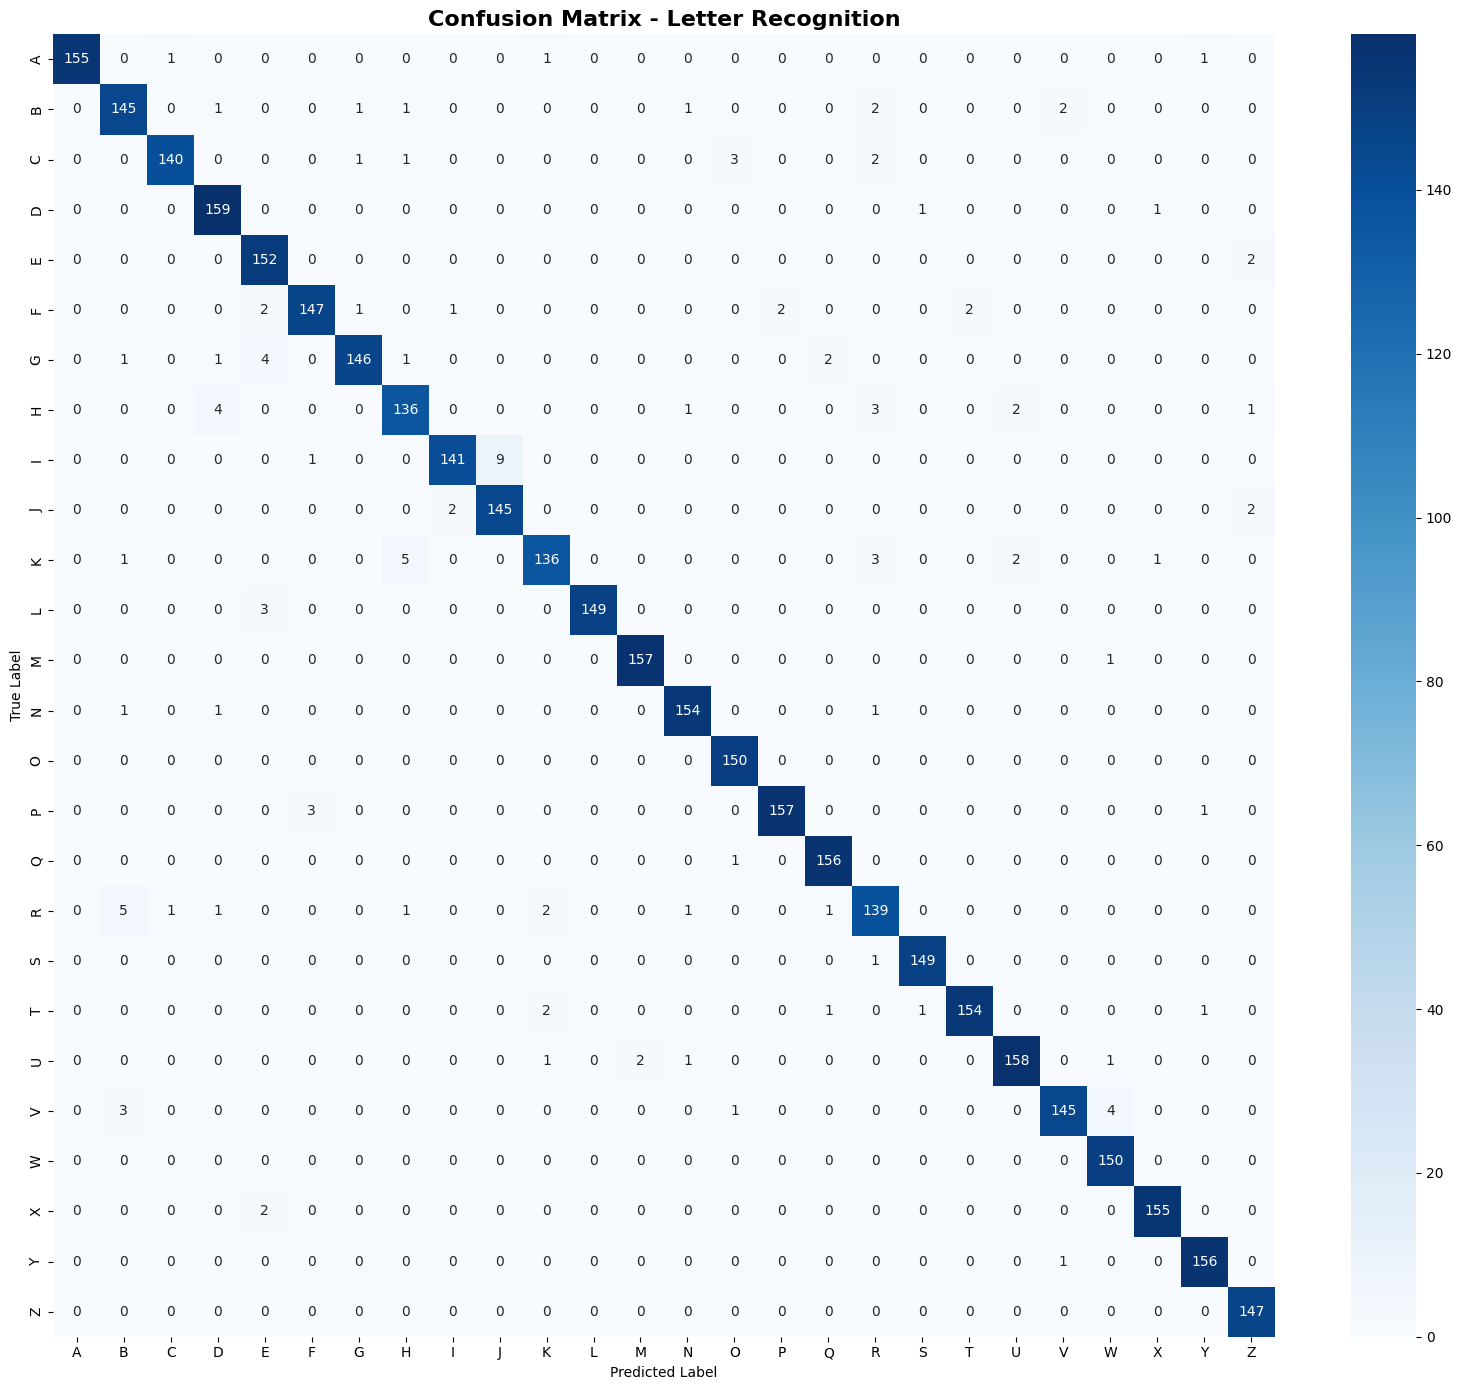

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_enc_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Letter Recognition', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('dl2a_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Predict on New Sample

In [10]:
# Predict a random sample from test set
idx = np.random.randint(0, X_test_sc.shape[0])
sample = X_test_sc[idx].reshape(1, -1)

pred_probs = model.predict(sample)[0]
pred_class = le.classes_[np.argmax(pred_probs)]
true_class = le.classes_[y_enc_test[idx]]
confidence = pred_probs.max() * 100

print(f'True Label      : {true_class}')
print(f'Predicted Label : {pred_class}')
print(f'Confidence      : {confidence:.2f}%')
print(f'Correct?        : {"✅ Yes" if pred_class == true_class else "❌ No"}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
True Label      : N
Predicted Label : N
Confidence      : 100.00%
Correct?        : ✅ Yes


---
## Conclusion
We successfully built a **Multiclass Classification DNN** that classifies handwritten character features into 26 letter classes (A–Z) using the OCR Letter Recognition dataset. The model uses `softmax` activation in the output layer and `categorical_crossentropy` as the loss function, achieving high accuracy on the test set.

---
## Viva Questions
**Q1. What is Batch Size?**  
The number of training samples processed in one forward/backward pass before model weights are updated. Smaller batch = more updates per epoch, more noise. Larger batch = fewer updates, more stable.

**Q2. What is Dropout?**  
A regularization technique that randomly sets a fraction of neurons to zero during each training step. It prevents overfitting by ensuring the network doesn't rely on any single neuron.

**Q3. What is RMSprop?**  
An adaptive learning rate optimizer that divides the learning rate by an exponentially decaying average of squared gradients. It works well for non-stationary objectives and RNNs.

**Q4. Loss functions available:**  
- `mean_squared_error` – regression tasks  
- `binary_crossentropy` – binary classification  
- `categorical_crossentropy` – multiclass classification (one-hot labels)  
- `sparse_categorical_crossentropy` – multiclass (integer labels)  
- `huber` – robust regression